load and clean data

In [2]:
import pandas as pd

# Load data
df = pd.read_csv('monthly_price_quantity_summary.csv')

# Drop rows with missing pct_price_change (first month of each item)
df_clean = df.dropna(subset=['pct_price_change'])

# Add a 'price_elasticity' flag (e.g., if sales drop when price rises)
df_clean['price_elasticity'] = df_clean.apply(
    lambda x: 'Elastic' if (x['pct_price_change'] > 0 and x['quantity_sold'] < 0) else 'Inelastic', 
    axis=1
)

C:\Users\fredn\AppData\Local\Temp\ipykernel_11764\3921325144.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['price_elasticity'] = df_clean.apply(


2. Correlation Analysis (Pandas)

In [3]:
# Global correlation
global_corr = df_clean[['pct_price_change', 'quantity_sold']].corr(method='pearson').iloc[0, 1]

# Per-item correlation
item_corr = df_clean.groupby('itemid')[['pct_price_change', 'quantity_sold']].corr().iloc[::2, -1]
item_corr = item_corr.reset_index().rename(columns={'quantity_sold': 'correlation'})

matlib visualization

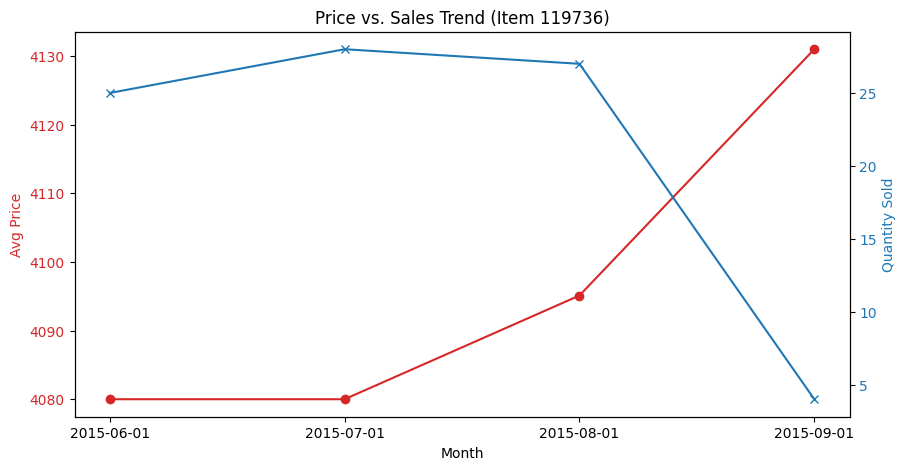

In [4]:
import matplotlib.pyplot as plt

# Example for one item (repeat for others)
item = 119736
df_item = df_clean[df_clean['itemid'] == item]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Price', color='tab:red')
ax1.plot(df_item['month'], df_item['avg_price'], color='tab:red', marker='o')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Quantity Sold', color='tab:blue')
ax2.plot(df_item['month'], df_item['quantity_sold'], color='tab:blue', marker='x')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title(f'Price vs. Sales Trend (Item {item})')
plt.show()

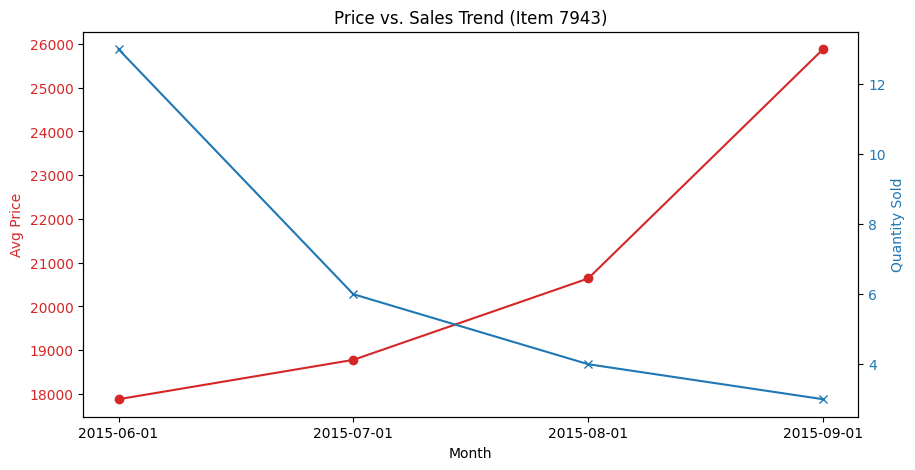

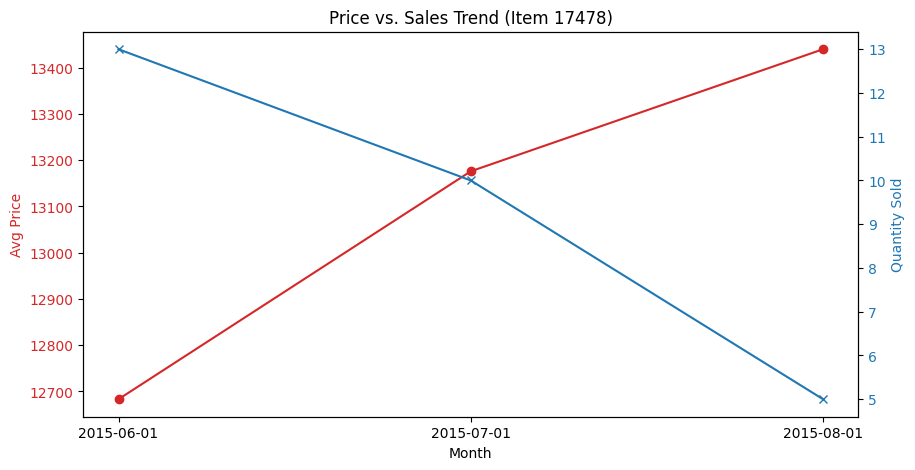

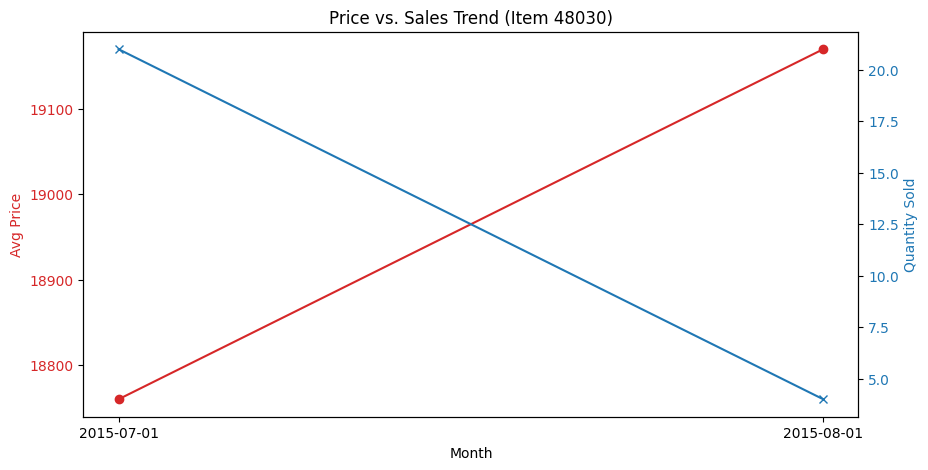

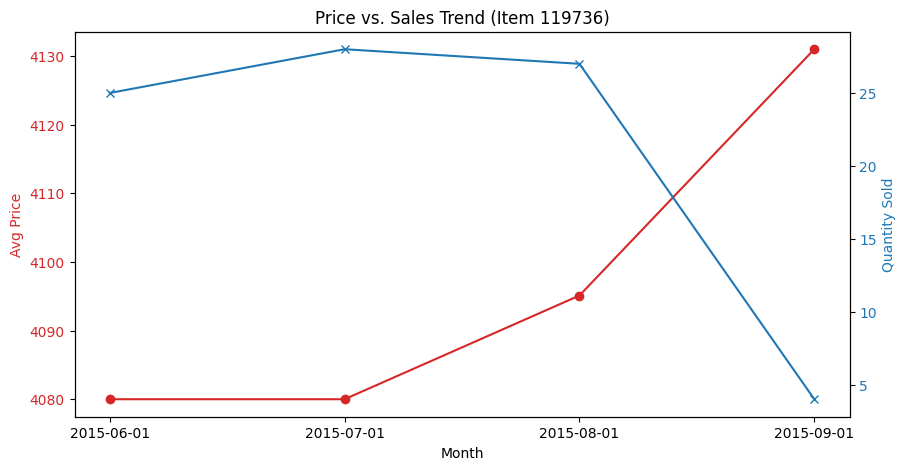

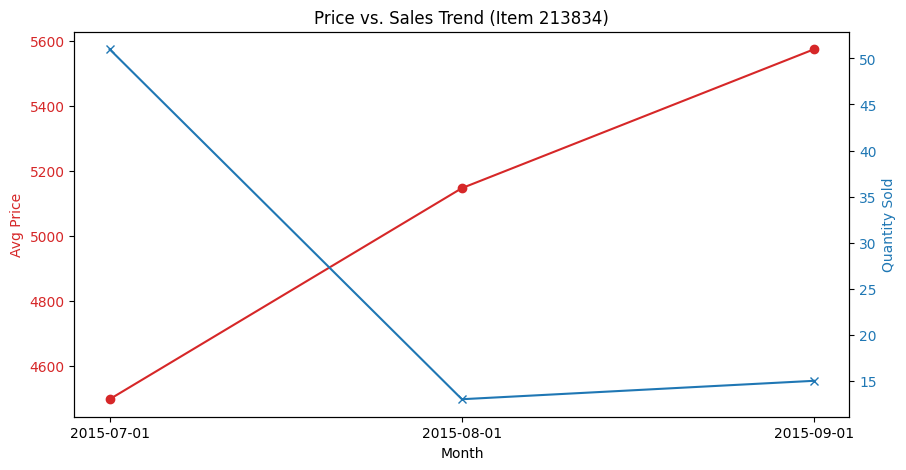

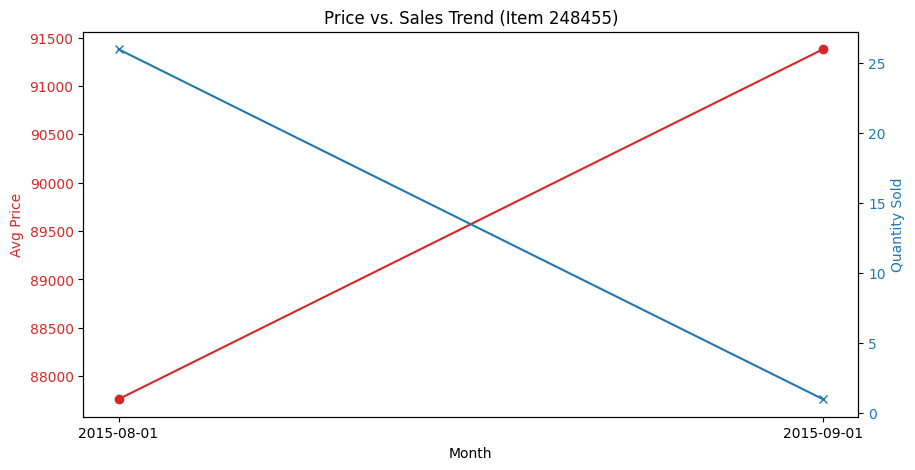

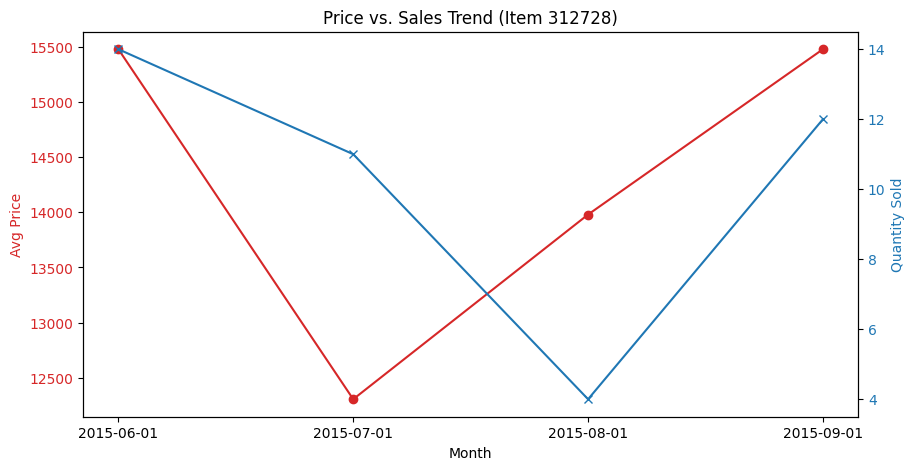

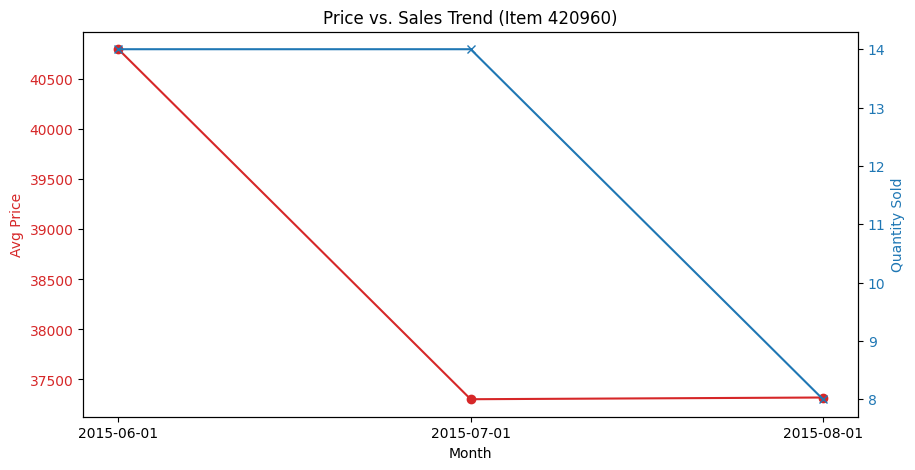

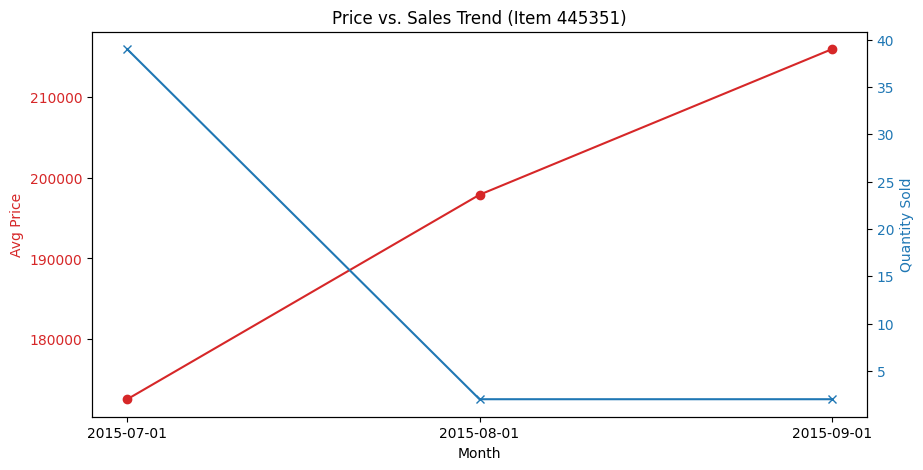

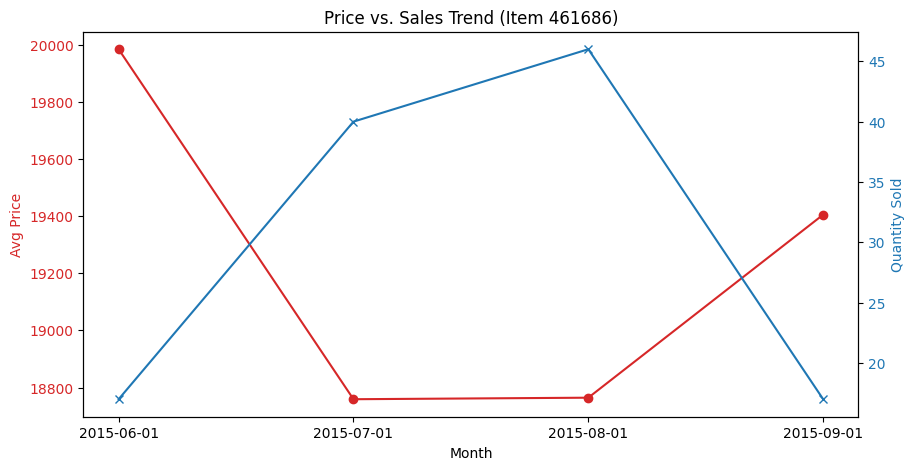

In [9]:
import matplotlib.pyplot as plt
for i in[7943,17478,48030,119736,213834,248455,312728,420960,445351,461686]:
    item=i

    # Example for one item (repeat for others)
    #item = 119736
    df_item = df_clean[df_clean['itemid'] == item]

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel('Month')
    ax1.set_ylabel('Avg Price', color='tab:red')
    ax1.plot(df_item['month'], df_item['avg_price'], color='tab:red', marker='o')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Quantity Sold', color='tab:blue')
    ax2.plot(df_item['month'], df_item['quantity_sold'], color='tab:blue', marker='x')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(f'Price vs. Sales Trend (Item {item})')
    plt.show()

 Scatter Plot (All Items)
 

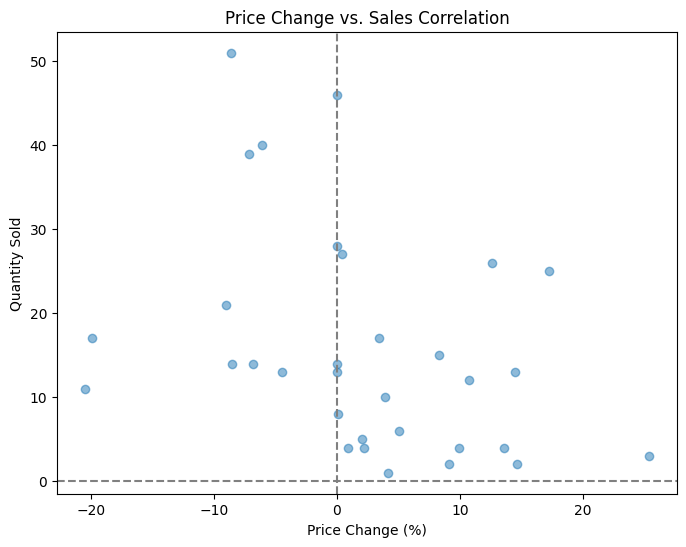

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['pct_price_change'], df_clean['quantity_sold'], alpha=0.5)
plt.xlabel('Price Change (%)')
plt.ylabel('Quantity Sold')
plt.title('Price Change vs. Sales Correlation')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.show()

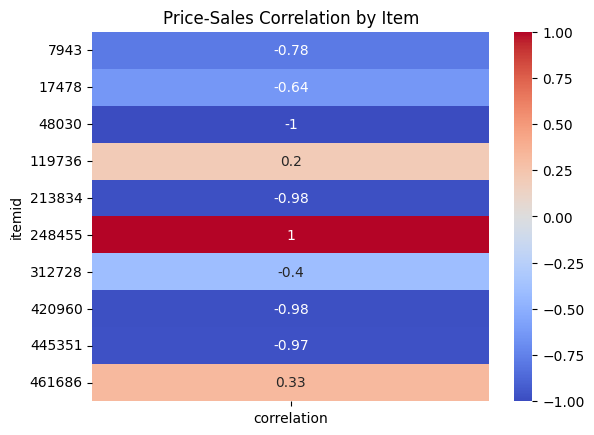

In [11]:
import seaborn as sns

# Pivot for heatmap
heatmap_data = item_corr.pivot_table(index='itemid', values='correlation')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)
plt.title('Price-Sales Correlation by Item')
plt.show()

In [12]:
print(item_corr.sort_values('correlation').head(5))  # Most negative (elastic)
print(item_corr.sort_values('correlation', ascending=False).head(5))  # Most positive (inelastic)

   itemid           level_1  correlation
2   48030  pct_price_change    -1.000000
7  420960  pct_price_change    -0.982011
4  213834  pct_price_change    -0.977291
8  445351  pct_price_change    -0.969455
0    7943  pct_price_change    -0.782138
   itemid           level_1  correlation
5  248455  pct_price_change     1.000000
9  461686  pct_price_change     0.327443
3  119736  pct_price_change     0.195430
6  312728  pct_price_change    -0.404925
1   17478  pct_price_change    -0.635069


In [13]:
print(f"Overall correlation: {global_corr:.2f}")

Overall correlation: -0.35


-0.25 > r > -0.5	Weak relationship